# Notebook 08 — Live Detection Simulation
## COM668 Final Year Project: AI-Based Intrusion Detection System
**Student:** Abdulbosit Abdurazzakov | **ID:** B00979380

---

### Purpose
This notebook streams individual network flows from the CICIDS2017 test set through the trained **Random Forest**, **Isolation Forest**, and **OR Ensemble** models one at a time, rendering a live SOC-style monitoring dashboard.

> **How to run:** Execute cells 1–4 to load data, then run **Cell 5** (the simulation loop).

| Parameter | Default | Effect |
|-----------|---------|--------|
| `N_FLOWS` | 300 | Flows to stream |
| `DELAY` | 0.05 s | Pause between flows — lower = faster |
| `ATTACK_BOOST` | 3 | Over-samples attacks for visual impact |


In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
from IPython.display import display, HTML, Image, clear_output

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 110

BASE   = os.path.join(os.path.dirname(os.path.abspath('__file__')), '..')
PROC   = os.path.join(BASE, 'data', 'processed')
RAW    = os.path.join(BASE, 'data')
MODELS = os.path.join(BASE, 'models')

print('Libraries loaded')
print(f'  BASE : {os.path.abspath(BASE)}')


Libraries loaded
  BASE : c:\Projects\cyber_ids_project


In [2]:
scaler        = joblib.load(os.path.join(PROC, 'scaler.pkl'))
le            = joblib.load(os.path.join(PROC, 'label_encoder.pkl'))
feature_names = joblib.load(os.path.join(PROC, 'feature_names.pkl'))
rf_model      = joblib.load(os.path.join(MODELS, 'random_forest.pkl'))
iso_model     = joblib.load(os.path.join(MODELS, 'isolation_forest.pkl'))

print(f'Label classes   : {list(le.classes_)}  (ATTACK=0, BENIGN=1)')
print(f'Features        : {len(feature_names)}')
print(f'Random Forest   : {rf_model.n_estimators} trees')
print(f'Isolation Forest: {iso_model.n_estimators} trees')


Label classes   : ['ATTACK', 'BENIGN']  (ATTACK=0, BENIGN=1)
Features        : 78
Random Forest   : 150 trees
Isolation Forest: 100 trees


In [3]:
TEST_FILES = [
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
]

print('Loading test CSVs ...')
dfs = []
for fname in TEST_FILES:
    fpath = os.path.join(RAW, fname)
    df = pd.read_csv(fpath, low_memory=False)
    df.columns = df.columns.str.strip()
    dfs.append(df)
    print(f'  {fname.split(".")[0]:<50} {len(df):>8,} rows')

df_test = pd.concat(dfs, ignore_index=True)
df_test.replace([np.inf, -np.inf], np.nan, inplace=True)
df_test.dropna(inplace=True)
df_test['BinaryLabel'] = df_test['Label'].apply(
    lambda x: 'BENIGN' if x.strip() == 'BENIGN' else 'ATTACK'
)
y_raw          = le.transform(df_test['BinaryLabel'])
X_raw          = df_test[feature_names].values
X_scaled       = scaler.transform(X_raw)
attack_type_raw = df_test['Label'].str.strip().values

n_att = (y_raw == 0).sum(); n_ben = (y_raw == 1).sum()
print(f'\nCombined test set  : {len(df_test):,} rows')
print(f'  ATTACK  : {n_att:>10,}  ({100*n_att/len(y_raw):.1f}%)')
print(f'  BENIGN  : {n_ben:>10,}  ({100*n_ben/len(y_raw):.1f}%)')
print('\nData ready for simulation')


Loading test CSVs ...
  Thursday-WorkingHours-Morning-WebAttacks            170,366 rows
  Thursday-WorkingHours-Afternoon-Infilteration       288,602 rows
  Friday-WorkingHours-Morning                         191,033 rows
  Friday-WorkingHours-Afternoon-DDos                  225,745 rows
  Friday-WorkingHours-Afternoon-PortScan              286,467 rows

Combined test set  : 1,161,344 rows
  ATTACK  :    291,001  (25.1%)
  BENIGN  :    870,343  (74.9%)

Data ready for simulation


In [4]:
# ── Simulation config — adjust these freely ──────────────────────────────
N_FLOWS      = 300    # total flows to stream
DELAY        = 0.05   # seconds between flows  (0 = max speed)
ATTACK_BOOST = 3      # oversample attacks this many times vs natural rate
LOG_ROWS     = 14     # rows shown in the live log panel
SEED         = 42
# ─────────────────────────────────────────────────────────────────────────

rng = np.random.default_rng(SEED)
attack_idx = np.where(y_raw == 0)[0]
benign_idx = np.where(y_raw == 1)[0]
n_att_s = min(int(N_FLOWS * ATTACK_BOOST / (ATTACK_BOOST + 1)), len(attack_idx))
n_ben_s = min(N_FLOWS - n_att_s, len(benign_idx))
chosen  = np.concatenate([
    rng.choice(attack_idx, n_att_s, replace=False),
    rng.choice(benign_idx, n_ben_s, replace=False),
])
rng.shuffle(chosen)
X_sample    = X_scaled[chosen]
y_sample    = y_raw[chosen]
type_sample = attack_type_raw[chosen]

print(f'Simulation sample : {len(chosen)} flows')
print(f'  ATTACK  : {(y_sample==0).sum()}')
print(f'  BENIGN  : {(y_sample==1).sum()}')


Simulation sample : 300 flows
  ATTACK  : 225
  BENIGN  : 75


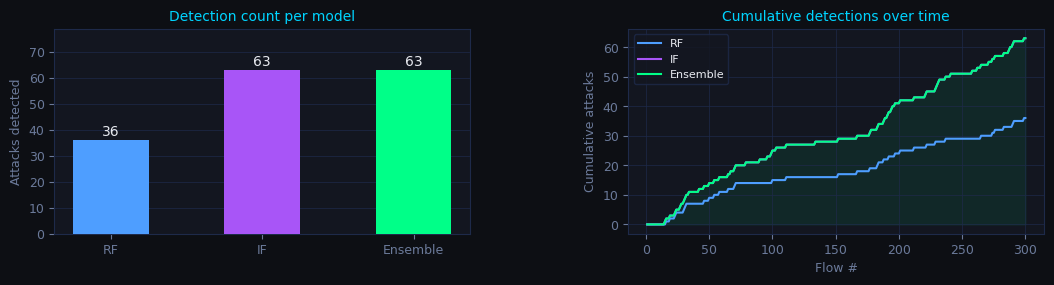


✓ Simulation complete — 300 flows in 71.4s  (4.2 flows/s)


In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  LIVE DETECTION SIMULATION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

import tempfile
TMP_CHART = os.path.join(tempfile.gettempdir(), '_ids_live.png')

C_BG      = '#0d0f14'
C_PANEL   = '#131620'
C_BORDER  = '#1e2a4a'
C_GREEN   = '#00ff88'
C_RED     = '#ff3355'
C_YELLOW  = '#ffd700'
C_CYAN    = '#00d4ff'
C_GREY    = '#6b7a9a'
C_WHITE   = '#e8eaf0'

MODEL_COLORS = {
    'RF':       '#4e9eff',
    'IF':       '#a855f7',
    'Ensemble': '#00ff88',
}

counters = {m: {'attack': 0, 'benign': 0} for m in ['RF', 'IF', 'Ensemble']}
log      = []
tl_rf    = []
tl_if    = []
tl_ens   = []

start_time = time.time()

def pct_bar(val, total, color, width=220):
    pct = (val / total * 100) if total > 0 else 0
    return (
        '<div style="background:#1a2035;border-radius:3px;width:' + str(width) + 'px;'
        'height:8px;display:inline-block;vertical-align:middle;">'
        '<div style="background:' + color + ';width:' + f'{pct:.1f}' + '%;height:100%;border-radius:3px;"></div></div> '
        '<span style="color:' + C_GREY + ';font-size:11px;">' + f'{pct:.0f}' + '%</span>'
    )

def badge(label, true_label=None):
    col = C_RED if label == 'ATTACK' else C_GREEN
    txt = '&#9888; ATTACK' if label == 'ATTACK' else '&#10003; BENIGN'
    border = ('outline:1px dashed ' + C_YELLOW + ';') if (true_label is not None and label != true_label) else ''
    return (
        '<span style="background:' + col + '22;color:' + col + ';border:1px solid ' + col + '55;'
        + border + 'padding:1px 6px;border-radius:3px;font-size:11px;font-weight:bold;">'
        + txt + '</span>'
    )

def render_html(i, total, elapsed):
    n   = i + 1
    fps = n / max(elapsed, 0.001)
    progress_pct = 100 * n / total

    parts = []
    parts.append(
        '<div style="background:' + C_BG + ';color:' + C_WHITE + ';'
        "font-family:'Courier New',monospace;"
        'padding:18px 22px;border-radius:10px;border:1px solid ' + C_BORDER + ';'
        'max-width:900px;margin:0 auto;">'
    )

    # Title bar
    parts.append(
        '<div style="display:flex;justify-content:space-between;align-items:center;'
        'border-bottom:1px solid ' + C_BORDER + ';padding-bottom:10px;margin-bottom:14px;">'
        '<div>'
        '<span style="color:' + C_CYAN + ';font-size:17px;font-weight:bold;letter-spacing:1px;">'
        '&#9616; AI-IDS LIVE MONITOR &#9616;</span>'
        '<span style="color:' + C_GREY + ';font-size:12px;margin-left:12px;">COM668 &middot; CICIDS2017 Test Set</span>'
        '</div>'
        '<div style="color:' + C_GREY + ';font-size:12px;">'
        '&#8987; ' + f'{elapsed:.1f}' + 's &nbsp;|&nbsp; ' + f'{fps:.1f}' + ' flows/s'
        ' &nbsp;|&nbsp; <span style="color:' + C_YELLOW + ';">LIVE</span>'
        '</div></div>'
    )

    # Progress bar
    parts.append(
        '<div style="margin-bottom:14px;">'
        '<div style="display:flex;justify-content:space-between;font-size:11px;color:' + C_GREY + ';margin-bottom:4px;">'
        '<span>FLOWS PROCESSED</span>'
        '<span>' + f'{n:,}' + ' / ' + f'{total:,}' + '</span></div>'
        '<div style="background:#1a2035;border-radius:4px;height:10px;">'
        '<div style="background:linear-gradient(90deg,' + C_CYAN + ',' + C_GREEN + ');'
        'width:' + f'{progress_pct:.1f}' + '%;height:100%;border-radius:4px;"></div>'
        '</div></div>'
    )

    # 3-column model counters
    parts.append('<div style="display:grid;grid-template-columns:1fr 1fr 1fr;gap:12px;margin-bottom:16px;">')
    for model, col in MODEL_COLORS.items():
        c = counters[model]
        total_seen = c['attack'] + c['benign']
        dr = (c['attack'] / total_seen * 100) if total_seen > 0 else 0
        parts.append(
            '<div style="background:' + C_PANEL + ';border:1px solid ' + col + '44;border-radius:8px;padding:12px;">'
            '<div style="color:' + col + ';font-size:13px;font-weight:bold;margin-bottom:8px;letter-spacing:1px;">'
            '&#9672; ' + model + '</div>'
            '<div style="font-size:26px;font-weight:bold;color:' + C_RED + ';margin-bottom:2px;">'
            + f'{c["attack"]:,}' + '</div>'
            '<div style="font-size:10px;color:' + C_GREY + ';margin-bottom:8px;">ATTACKS DETECTED</div>'
            + pct_bar(c['attack'], total_seen, C_RED, 150) +
            '<div style="margin-top:8px;font-size:11px;color:' + C_GREY + ';">'
            'Benign: <span style="color:' + C_GREEN + ';">' + f'{c["benign"]:,}' + '</span>'
            ' &nbsp;|&nbsp; DR: <span style="color:' + col + ';">' + f'{dr:.0f}' + '%</span>'
            '</div></div>'
        )
    parts.append('</div>')

    # Rolling log table
    parts.append(
        '<div style="border:1px solid ' + C_BORDER + ';border-radius:6px;overflow:hidden;">'
        '<div style="background:#0f1420;padding:6px 12px;border-bottom:1px solid ' + C_BORDER + ';'
        'font-size:11px;color:' + C_GREY + ';display:grid;'
        'grid-template-columns:50px 60px 150px 1fr 1fr 1fr;">'
        '<span>#</span>'
        '<span>TRUTH</span>'
        '<span>ATTACK TYPE</span>'
        '<span style="color:' + MODEL_COLORS['RF'] + ';">RF</span>'
        '<span style="color:' + MODEL_COLORS['IF'] + ';">IF</span>'
        '<span style="color:' + MODEL_COLORS['Ensemble'] + ';">ENSEMBLE</span>'
        '</div>'
    )
    for row in reversed(log[-LOG_ROWS:]):
        row_bg = C_RED + '0a' if row['true'] == 'ATTACK' else 'transparent'
        atype  = row.get('atype', 'BENIGN')
        if atype == 'BENIGN':
            atype_disp = '<span style="color:' + C_GREY + ';">BENIGN</span>'
        else:
            atype_disp = '<span style="color:' + C_YELLOW + ';font-size:10px;">' + atype[:22] + '</span>'
        parts.append(
            '<div style="background:' + row_bg + ';padding:4px 12px;'
            'border-bottom:1px solid ' + C_BORDER + '11;font-size:11px;display:grid;'
            'grid-template-columns:50px 60px 150px 1fr 1fr 1fr;align-items:center;">'
            '<span style="color:' + C_GREY + ';">' + str(row['flow']) + '</span>'
            + badge(row['true']) +
            '<span>' + atype_disp + '</span>'
            + badge(row['rf'], row['true'])
            + badge(row['if_'], row['true'])
            + badge(row['ens'], row['true']) +
            '</div>'
        )
    parts.append('</div>')
    parts.append('</div>')
    return ''.join(parts)

def render_figure(i):
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    import numpy as np
    fig = plt.figure(figsize=(11, 3.2), facecolor=C_BG)
    gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.38, left=0.07, right=0.97,
                             top=0.82, bottom=0.18)

    ax1 = fig.add_subplot(gs[0])
    ax1.set_facecolor(C_PANEL)
    models = ['RF', 'IF', 'Ensemble']
    vals   = [counters[m]['attack'] for m in models]
    cols   = [MODEL_COLORS[m] for m in models]
    bars   = ax1.bar(models, vals, color=cols, width=0.5, zorder=3, edgecolor='none')
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(v), ha='center', va='bottom', color=C_WHITE, fontsize=10)
    ax1.set_ylabel('Attacks detected', color=C_GREY, fontsize=9)
    ax1.set_title('Detection count per model', color=C_CYAN, fontsize=10, pad=6)
    ax1.set_ylim(0, max(max(vals) * 1.25, 10))
    ax1.tick_params(colors=C_GREY, labelsize=9)
    for spine in ax1.spines.values(): spine.set_color(C_BORDER)
    ax1.grid(axis='y', color=C_BORDER, linewidth=0.5, zorder=0)

    ax2 = fig.add_subplot(gs[1])
    ax2.set_facecolor(C_PANEL)
    xs = np.arange(1, len(tl_rf)+1)
    if len(xs) > 0:
        ax2.plot(xs, tl_rf,  color=MODEL_COLORS['RF'],       lw=1.5, label='RF')
        ax2.plot(xs, tl_if,  color=MODEL_COLORS['IF'],       lw=1.5, label='IF')
        ax2.plot(xs, tl_ens, color=MODEL_COLORS['Ensemble'], lw=1.5, label='Ensemble')
        ax2.fill_between(xs, tl_ens, alpha=0.08, color=MODEL_COLORS['Ensemble'])
    ax2.set_xlabel('Flow #', color=C_GREY, fontsize=9)
    ax2.set_ylabel('Cumulative attacks', color=C_GREY, fontsize=9)
    ax2.set_title('Cumulative detections over time', color=C_CYAN, fontsize=10, pad=6)
    ax2.tick_params(colors=C_GREY, labelsize=9)
    for spine in ax2.spines.values(): spine.set_color(C_BORDER)
    ax2.grid(color=C_BORDER, linewidth=0.5, zorder=0)
    ax2.legend(fontsize=8, facecolor=C_PANEL, edgecolor=C_BORDER, labelcolor=C_WHITE, loc='upper left')
    fig.patch.set_facecolor(C_BG)
    plt.savefig(TMP_CHART, dpi=100, facecolor=C_BG, bbox_inches='tight')
    plt.close(fig)

# ─────────────────────────────────────────────────────────────────────────────
#  MAIN LOOP
# ─────────────────────────────────────────────────────────────────────────────
from IPython.display import display, HTML, Image, clear_output
total = len(X_sample)
print(f"Starting simulation: {total} flows …  (Ctrl-C to stop)")
time.sleep(0.5)

for i, (x_row, y_true, atype) in enumerate(zip(X_sample, y_sample, type_sample)):
    x = x_row.reshape(1, -1)

    rf_pred   = rf_model.predict(x)[0]
    rf_label  = 'ATTACK' if rf_pred == 0 else 'BENIGN'
    if_raw    = iso_model.predict(x)[0]
    if_pred   = 0 if if_raw == -1 else 1
    if_label  = 'ATTACK' if if_pred == 0 else 'BENIGN'
    ens_pred  = 0 if (rf_pred == 0 or if_pred == 0) else 1
    ens_label = 'ATTACK' if ens_pred == 0 else 'BENIGN'
    true_label = 'ATTACK' if y_true == 0 else 'BENIGN'

    for model, label in [('RF', rf_label), ('IF', if_label), ('Ensemble', ens_label)]:
        counters[model]['attack' if label == 'ATTACK' else 'benign'] += 1

    tl_rf.append(counters['RF']['attack'])
    tl_if.append(counters['IF']['attack'])
    tl_ens.append(counters['Ensemble']['attack'])

    log.append({'flow': i+1, 'true': true_label, 'atype': atype,
                'rf': rf_label, 'if_': if_label, 'ens': ens_label})

    elapsed = time.time() - start_time
    if DELAY > 0 or (i % 3 == 0):
        render_figure(i)
        clear_output(wait=True)
        display(HTML(render_html(i, total, elapsed)))
        display(Image(TMP_CHART))

    if DELAY > 0:
        time.sleep(DELAY)

elapsed = time.time() - start_time
render_figure(total - 1)
clear_output(wait=True)
display(HTML(render_html(total - 1, total, elapsed)))
display(Image(TMP_CHART))
print(f"\n✓ Simulation complete — {total} flows in {elapsed:.1f}s  ({total/elapsed:.1f} flows/s)")


In [6]:
# ── Post-simulation accuracy summary ─────────────────────────────────────────
from sklearn.metrics import classification_report
import shutil, os

y_true_all = ['ATTACK' if y == 0 else 'BENIGN' for y in y_sample]
y_pred_rf  = []
y_pred_if  = []
y_pred_ens = []

for x_row in X_sample:
    x = x_row.reshape(1, -1)
    rf_p  = 0 if rf_model.predict(x)[0] == 0 else 1
    if_p  = 0 if iso_model.predict(x)[0] == -1 else 1
    ens_p = 0 if (rf_p == 0 or if_p == 0) else 1
    y_pred_rf.append('ATTACK' if rf_p == 0 else 'BENIGN')
    y_pred_if.append('ATTACK' if if_p == 0 else 'BENIGN')
    y_pred_ens.append('ATTACK' if ens_p == 0 else 'BENIGN')

print("=" * 60)
print("  SIMULATION ACCURACY SUMMARY  (sampled flows only)")
print("=" * 60)
for name, preds in [('Random Forest', y_pred_rf),
                    ('Isolation Forest', y_pred_if),
                    ('OR Ensemble', y_pred_ens)]:
    print(f"\n── {name} ──")
    print(classification_report(y_true_all, preds,
                                 target_names=['ATTACK','BENIGN'], digits=3))

results_dir = os.path.join(BASE, 'results')
os.makedirs(results_dir, exist_ok=True)
out_path = os.path.join(results_dir, '21_live_sim_final.png')
shutil.copy(TMP_CHART, out_path)
print(f"\n✓ Final chart saved → {out_path}")


  SIMULATION ACCURACY SUMMARY  (sampled flows only)

── Random Forest ──
              precision    recall  f1-score   support

      ATTACK      1.000     0.160     0.276       225
      BENIGN      0.284     1.000     0.442        75

    accuracy                          0.370       300
   macro avg      0.642     0.580     0.359       300
weighted avg      0.821     0.370     0.318       300


── Isolation Forest ──
              precision    recall  f1-score   support

      ATTACK      0.937     0.262     0.410       225
      BENIGN      0.300     0.947     0.455        75

    accuracy                          0.433       300
   macro avg      0.618     0.604     0.432       300
weighted avg      0.777     0.433     0.421       300


── OR Ensemble ──
              precision    recall  f1-score   support

      ATTACK      0.937     0.262     0.410       225
      BENIGN      0.300     0.947     0.455        75

    accuracy                          0.433       300
   macro avg